<a href="https://colab.research.google.com/github/Kimia998/Bridge-Sensor-Data-Analysis/blob/main/Bridge_Sensor_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
# =========================
# Imports
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# =========================
# Load data
# =========================
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DSlab-Bridges-Data.csv")
df_org=df.copy()

# =========================
# Basic inspection
# =========================
df.head()

,timestamp,bridge_id,temp_c,humidity,traffic_count,truck_count,wind_speed,strain_micro,vibration_mm,tilt_deg,displacement_mm,crack_sensor,anomaly
0,2025-01-01 00:00:00,1,-1.25,69.9,136,4,4.52,130.99,1.602,0.0219,0.692,0.1227,0
1,2025-01-01 01:00:00,1,-1.82,66.3,132,7,1.26,126.52,1.381,0.0186,0.640,0.1093,0
2,2025-01-01 02:00:00,1,0.10,62.8,122,2,3.32,132.22,1.368,0.0197,0.713,0.1293,0
3,2025-01-01 03:00:00,1,0.03,70.0,128,2,3.64,135.53,1.661,0.0227,0.834,0.1244,0
4,2025-01-01 04:00:00,1,1.29,67.8,118,5,2.39,136.69,1.417,0.0167,0.887,0.1181,0


In [3]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26280 entries, 0 to 26279
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   timestamp        26280 non-null  object 
 1   bridge_id        26280 non-null  int64  
 2   temp_c           26280 non-null  float64
 3   humidity         26280 non-null  float64
 4   traffic_count    26280 non-null  int64  
 5   truck_count      26280 non-null  int64  
 6   wind_speed       26280 non-null  float64
 7   strain_micro     26280 non-null  float64
 8   vibration_mm     26280 non-null  float64
 9   tilt_deg         26280 non-null  float64
 10  displacement_mm  26280 non-null  float64
 11  crack_sensor     26280 non-null  float64
 12  anomaly          26280 non-null  int64  
dtypes: float64(8), int64(4), object(1)
memory usage: 2.6+ MB


,count,mean,std,min,25%,50%,75%,max
bridge_id,26280.0,2.000000,0.816512,1.0000,1.0000,2.0000,3.0000,3.0000
temp_c,26280.0,10.001766,9.064517,-10.5300,2.2000,10.0300,17.8300,30.6100
humidity,26280.0,65.010259,6.746306,40.3000,60.3000,65.1000,69.7000,91.7000
traffic_count,26280.0,139.290639,56.022340,20.0000,98.0000,127.0000,177.0000,307.0000
truck_count,26280.0,10.919482,7.140998,0.0000,5.0000,10.0000,16.0000,39.0000
wind_speed,26280.0,3.030319,1.705136,0.0000,1.6800,3.0200,4.3600,8.3800
strain_micro,26280.0,145.526164,16.328428,102.0700,132.8900,144.1200,157.3900,227.6100
vibration_mm,26280.0,1.501466,0.239738,0.8220,1.3300,1.4840,1.6500,3.7260
tilt_deg,26280.0,0.022039,0.006894,0.0079,0.0164,0.0203,0.0290,0.0794
displacement_mm,26280.0,1.133010,0.335054,0.0610,0.8810,1.1350,1.3800,2.1900


In [58]:
# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Extract time features
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["weekday"] = df["timestamp"].dt.day_name()
df_extra=df.copy()
df.head()

,timestamp,bridge_id,temp_c,humidity,traffic_count,truck_count,wind_speed,strain_micro,vibration_mm,tilt_deg,displacement_mm,crack_sensor,anomaly,hour,day,weekday
0,2025-01-01 00:00:00,1,-1.25,69.9,136,4,4.52,130.99,1.602,0.0219,0.692,0.1227,0,0,1,Wednesday
1,2025-01-01 01:00:00,1,-1.82,66.3,132,7,1.26,126.52,1.381,0.0186,0.640,0.1093,0,1,1,Wednesday
2,2025-01-01 02:00:00,1,0.10,62.8,122,2,3.32,132.22,1.368,0.0197,0.713,0.1293,0,2,1,Wednesday
3,2025-01-01 03:00:00,1,0.03,70.0,128,2,3.64,135.53,1.661,0.0227,0.834,0.1244,0,3,1,Wednesday
4,2025-01-01 04:00:00,1,1.29,67.8,118,5,2.39,136.69,1.417,0.0167,0.887,0.1181,0,4,1,Wednesday


In [5]:
df

,timestamp,bridge_id,temp_c,humidity,traffic_count,truck_count,wind_speed,strain_micro,vibration_mm,tilt_deg,displacement_mm,crack_sensor,anomaly,hour,day,weekday
0,2025-01-01 00:00:00,1,-1.25,69.9,136,4,4.52,130.99,1.602,0.0219,0.692,0.1227,0,0,1,Wednesday
1,2025-01-01 01:00:00,1,-1.82,66.3,132,7,1.26,126.52,1.381,0.0186,0.640,0.1093,0,1,1,Wednesday
2,2025-01-01 02:00:00,1,0.10,62.8,122,2,3.32,132.22,1.368,0.0197,0.713,0.1293,0,2,1,Wednesday
3,2025-01-01 03:00:00,1,0.03,70.0,128,2,3.64,135.53,1.661,0.0227,0.834,0.1244,0,3,1,Wednesday
4,2025-01-01 04:00:00,1,1.29,67.8,118,5,2.39,136.69,1.417,0.0167,0.887,0.1181,0,4,1,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26275,2025-12-31 19:00:00,3,-8.80,66.1,189,12,3.45,129.69,1.453,0.0150,0.400,0.1804,0,19,31,Wednesday
26276,2025-12-31 20:00:00,3,-6.64,83.5,127,8,3.32,115.94,1.300,0.0178,0.470,0.1733,0,20,31,Wednesday
26277,2025-12-31 21:00:00,3,-3.95,61.7,124,4,3.94,114.97,1.232,0.0151,0.641,0.1761,0,21,31,Wednesday
26278,2025-12-31 22:00:00,3,-4.75,68.6,96,3,4.60,117.87,1.168,0.0135,0.470,0.1780,0,22,31,Wednesday


In [6]:
df.groupby("timestamp").value_counts()

timestamp            bridge_id  temp_c  humidity  traffic_count  truck_count  wind_speed  strain_micro  vibration_mm  tilt_deg  displacement_mm  crack_sensor  anomaly  hour  day  weekday  
2025-01-01 00:00:00  1          -1.25   69.9      136            4            4.52        130.99        1.602         0.0219    0.692            0.1227        0        0     1    Wednesday    1
                     2          -0.19   71.4      115            9            3.37        151.22        1.667         0.0281    1.056            0.1795        0        0     1    Wednesday    1
                     3          -4.09   66.6      106            14           3.59        118.05        1.155         0.0187    0.559            0.0856        0        0     1    Wednesday    1
2025-01-01 01:00:00  1          -1.82   66.3      132            7            1.26        126.52        1.381         0.0186    0.640            0.1093        0        1     1    Wednesday    1
                     2          -1.58   75.6      135            3            3.02        148.99        1.623         0.0347    0.876            0.1792        0        1     1    Wednesday    1
                                                                                                                                                                                               ..
2025-12-31 22:00:00  2          -5.40   79.8      113            3            3.28        151.24        1.632         0.0308    1.026            0.2640        0        22    31   Wednesday    1
                     3          -4.75   68.6      96             3            4.60        117.87        1.168         0.0135    0.470            0.1780        0        22    31   Wednesday    1
2025-12-31 23:00:00  1          -3.84   76.8      112            4            5.30        132.29        1.411         0.0185    0.509            0.2086        0        23    31   Wednesday    1
                     2          -3.18   78.7      109            1            3.35        148.88        1.578         0.0306    0.885            0.2591        0        23    31   Wednesday    1
                     3          -1.78   74.5      103            10           3.53        126.23        1.236         0.0159    0.672            0.1810        0        23    31   Wednesday    1
Name: count, Length: 26280, dtype: int64

In [7]:
# Missing values
df.isna().sum()

,0
timestamp,0
bridge_id,0
temp_c,0
humidity,0
traffic_count,0
truck_count,0
wind_speed,0
strain_micro,0
vibration_mm,0
tilt_deg,0


In [8]:
df["timestamp"].iloc[:6]

,timestamp
0,2025-01-01 00:00:00
1,2025-01-01 01:00:00
2,2025-01-01 02:00:00
3,2025-01-01 03:00:00
4,2025-01-01 04:00:00
5,2025-01-01 05:00:00


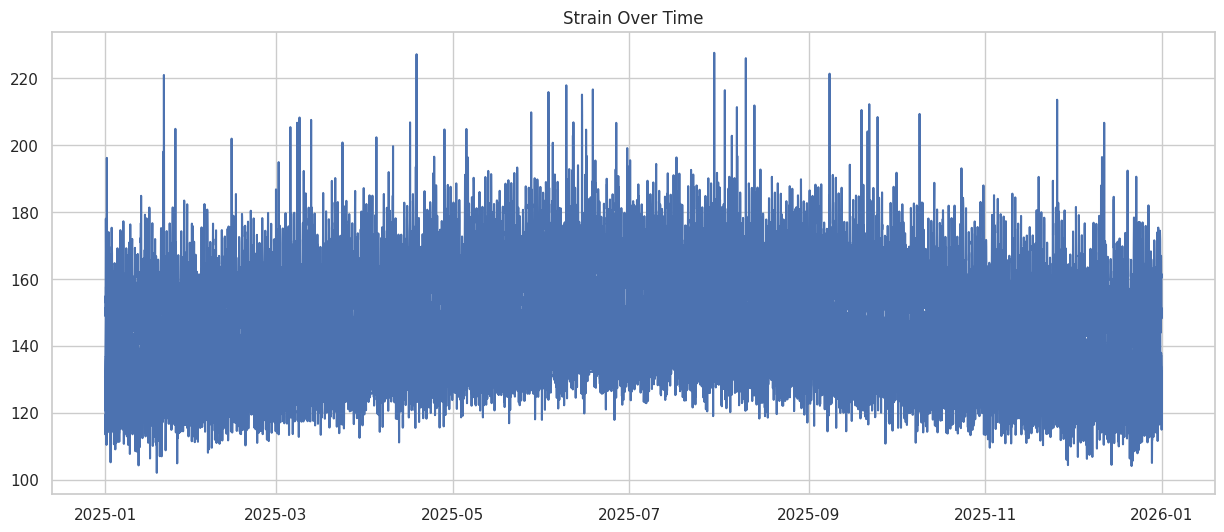

In [9]:
plt.figure(figsize=(15,6))
plt.plot(df["timestamp"], df["strain_micro"], label="Strain")
plt.title("Strain Over Time")
plt.show()

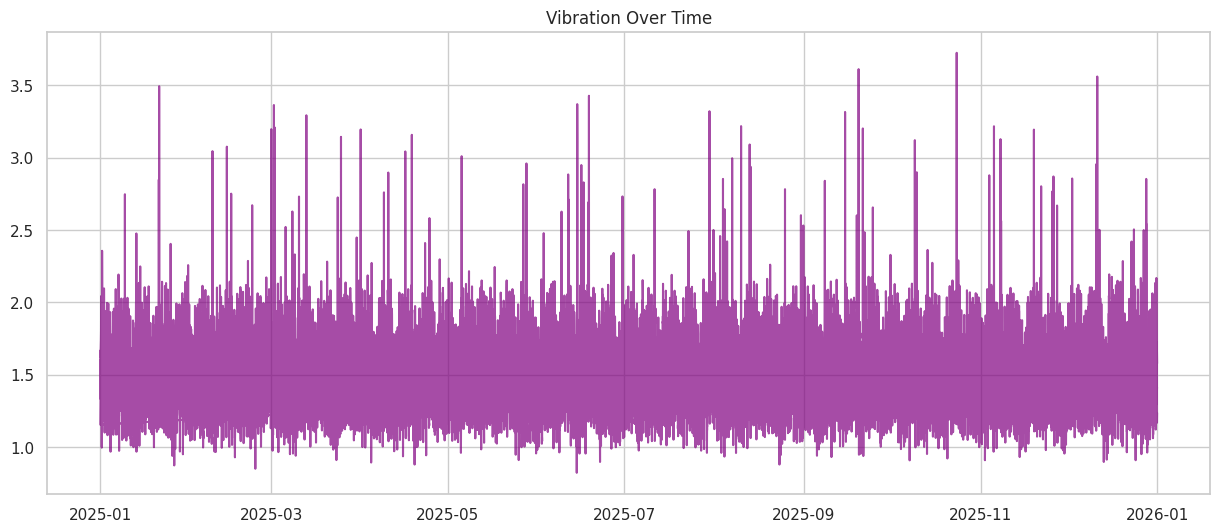

In [10]:
plt.figure(figsize=(15,6))
plt.plot(df["timestamp"], df["vibration_mm"], label="Vibration", alpha=0.7, color="purple")
plt.title("Vibration Over Time")
plt.show()

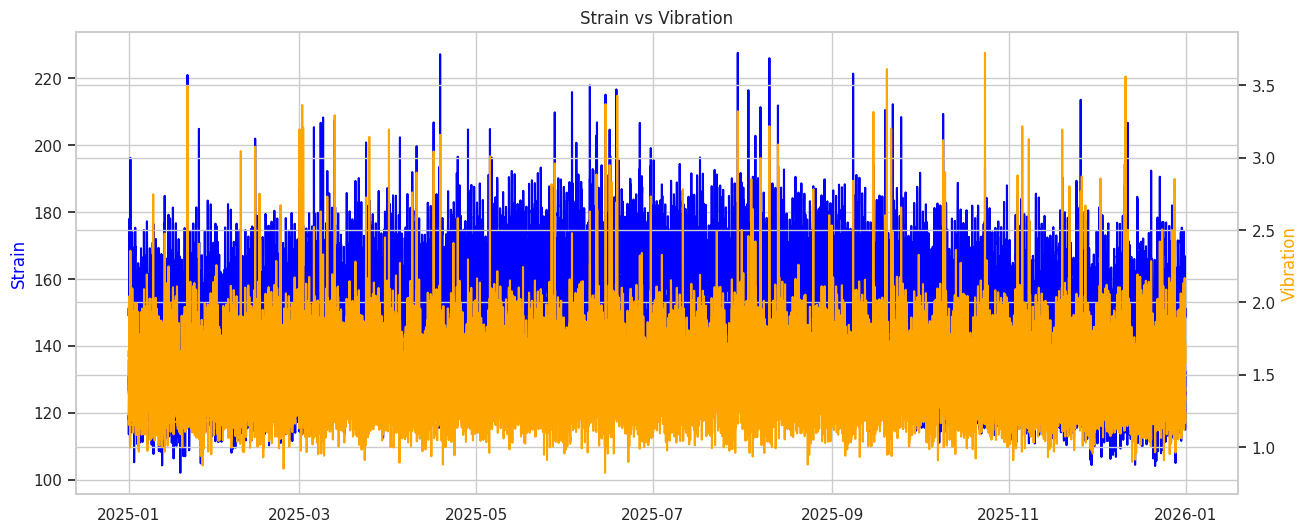

In [11]:
fig, ax1 = plt.subplots(figsize=(15,6))

ax1.plot(df["timestamp"], df["strain_micro"], color="blue")
ax1.set_ylabel("Strain", color="blue")

ax2 = ax1.twinx()
ax2.plot(df["timestamp"], df["vibration_mm"], color="orange")
ax2.set_ylabel("Vibration", color="orange")

plt.title("Strain vs Vibration")
plt.show()

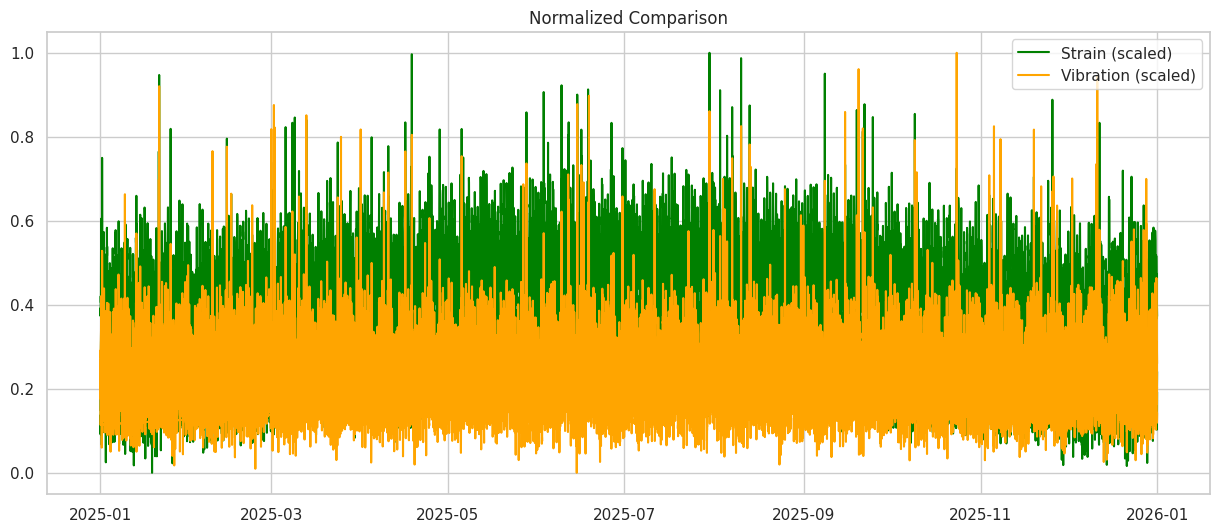

In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled = scaler.fit_transform(df[["strain_micro", "vibration_mm"]])
scaled_df = pd.DataFrame(scaled, columns=["strain_scaled", "vibration_scaled"])

plt.figure(figsize=(15,6))
plt.plot(df["timestamp"], scaled_df["strain_scaled"], label="Strain (scaled)",color="green")
plt.plot(df["timestamp"], scaled_df["vibration_scaled"], label="Vibration (scaled)", color="orange")
plt.legend()
plt.title("Normalized Comparison")
plt.show()

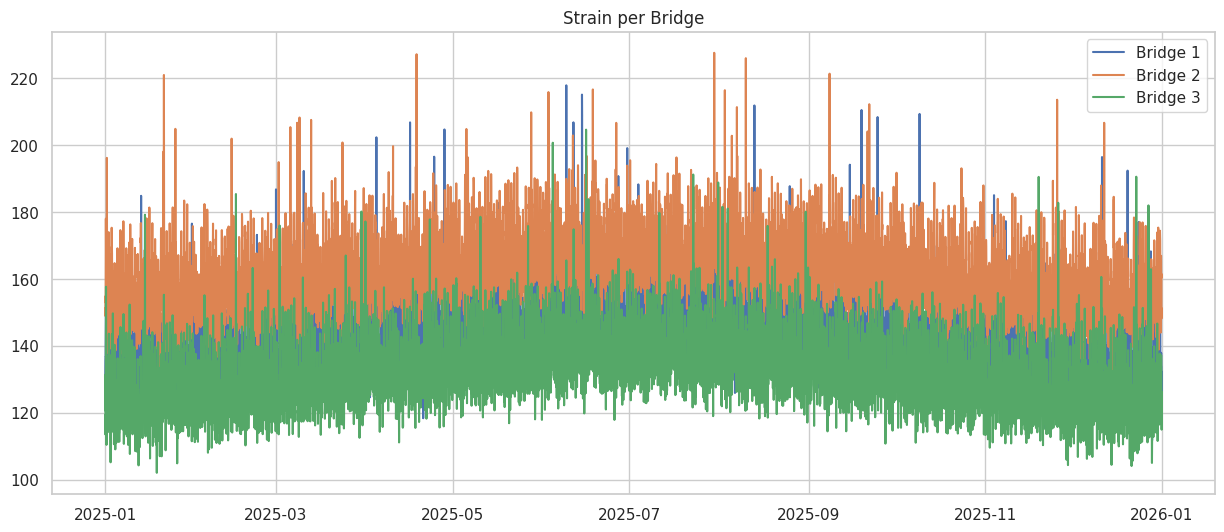

In [13]:
plt.figure(figsize=(15,6))

for b in df["bridge_id"].unique():
    subset = df[df["bridge_id"] == b]
    plt.plot(subset["timestamp"], subset["strain_micro"], label=f"Bridge {b}")

plt.legend()
plt.title("Strain per Bridge")
plt.show()

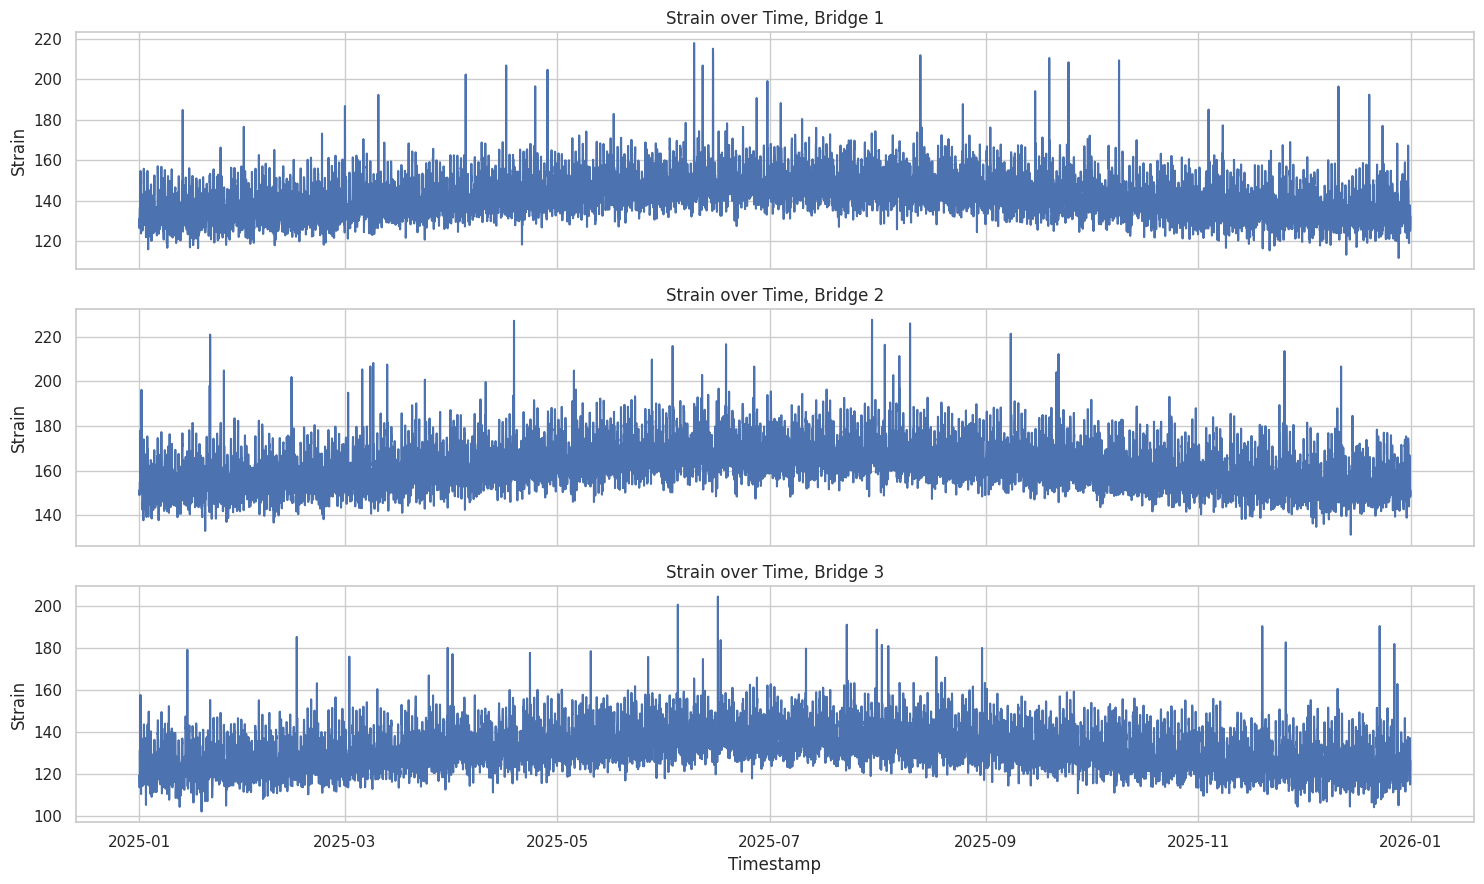

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)

for i, bridge in enumerate(sorted(df["bridge_id"].unique())):
    bridge_data = df[df["bridge_id"] == bridge]

    axes[i].plot(bridge_data["timestamp"], bridge_data["strain_micro"])
    axes[i].set_title(f"Strain over Time, Bridge {bridge}")
    axes[i].set_ylabel("Strain")

plt.xlabel("Timestamp")
plt.tight_layout()
plt.show()

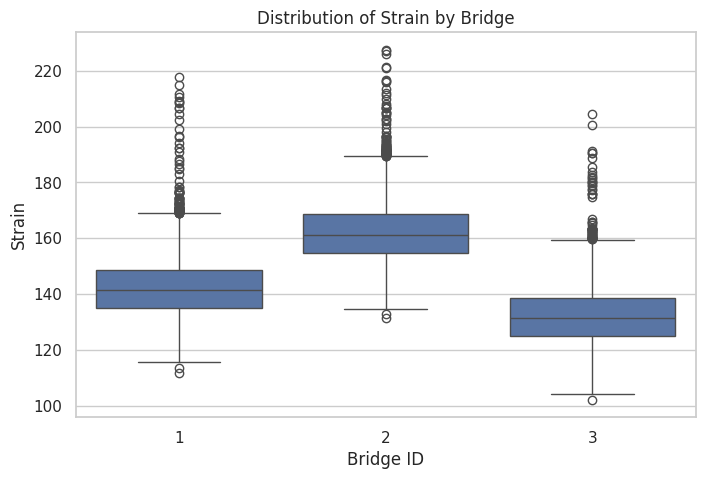

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="bridge_id", y="strain_micro")
plt.title("Distribution of Strain by Bridge")
plt.xlabel("Bridge ID")
plt.ylabel("Strain")
plt.show()

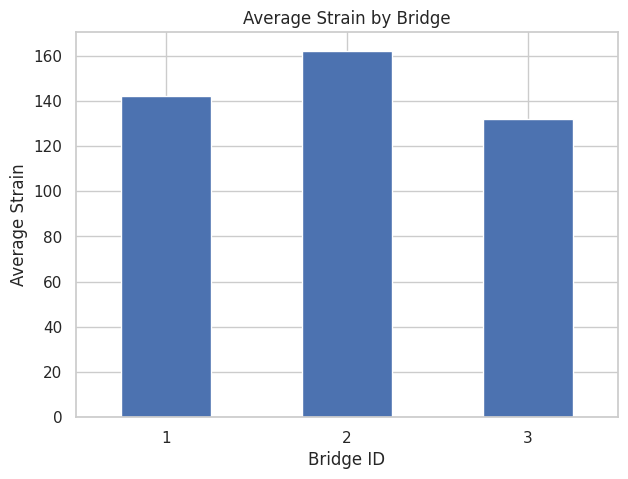

In [16]:
avg_strain = df.groupby("bridge_id")["strain_micro"].mean()

plt.figure(figsize=(7,5))
ax = avg_strain.plot(kind="bar")
plt.title("Average Strain by Bridge")
plt.xlabel("Bridge ID")
ax.tick_params(axis='x', rotation=0)
plt.ylabel("Average Strain")
plt.show()

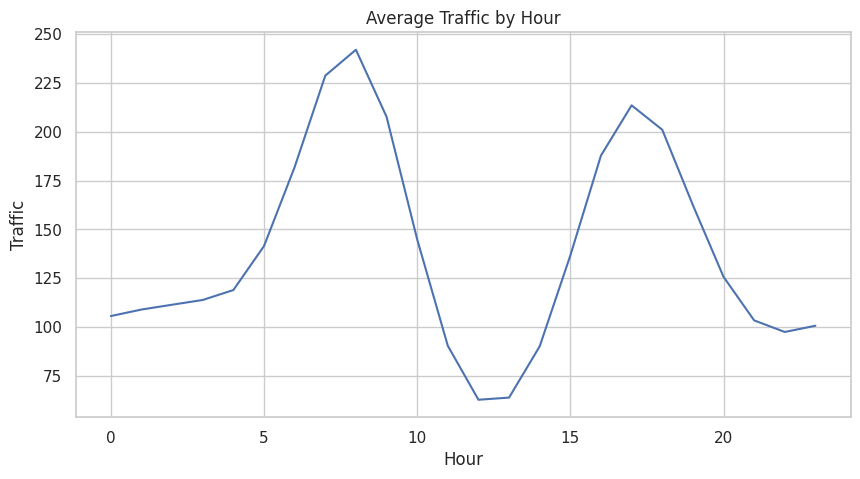

In [17]:
hourly_pattern = df.groupby("hour")["traffic_count"].mean()

plt.figure(figsize=(10,5))
hourly_pattern.plot()
plt.title("Average Traffic by Hour")
plt.xlabel("Hour")
plt.ylabel("Traffic")
plt.show()

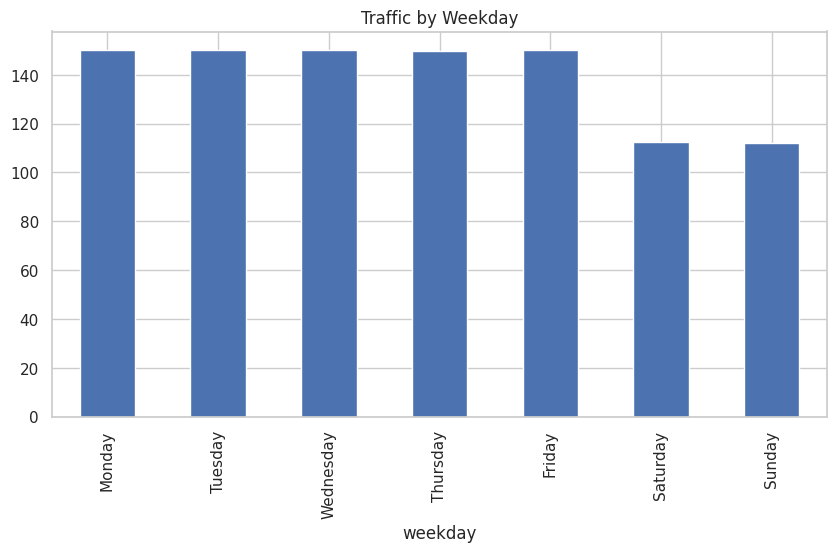

In [18]:
weekday_pattern = df.groupby("weekday")["traffic_count"].mean()

weekday_pattern = weekday_pattern.reindex([
    "Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"
])

plt.figure(figsize=(10,5))
weekday_pattern.plot(kind="bar")
plt.title("Traffic by Weekday")
plt.show()

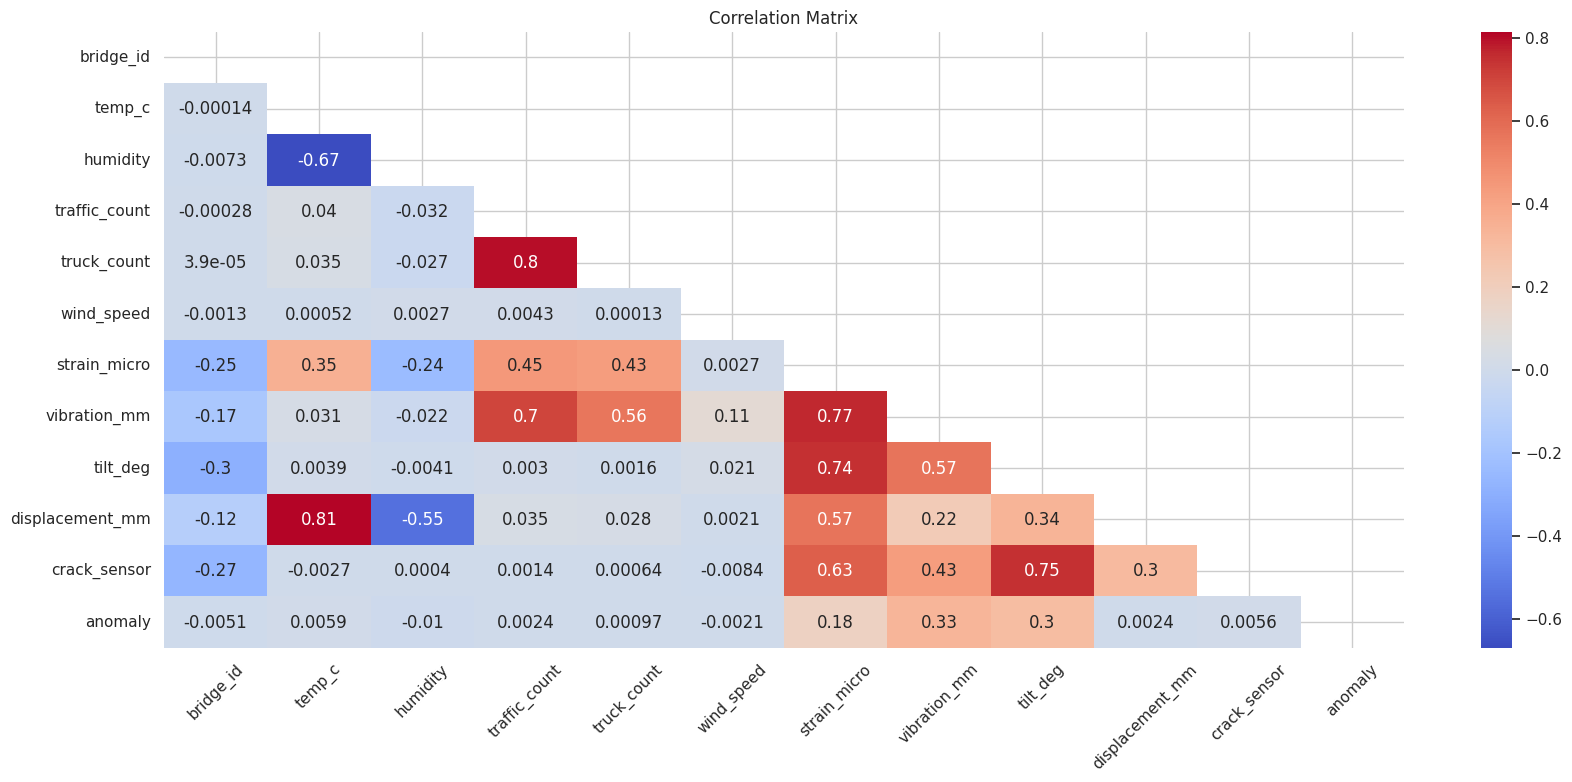

In [19]:
import numpy as np

plt.figure(figsize=(20,8))
corr_matrix = df_org.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
ax = sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", mask=mask)
plt.title("Correlation Matrix")
ax.tick_params(axis='x', rotation=45)
plt.show()

In [20]:
corr = df["traffic_count"].corr(df["strain_micro"])
print("Correlation traffic vs strain:", corr)
corr = df["temp_c"].corr(df["displacement_mm"])
print("Correlation temperature vs displacement:", corr)

Correlation traffic vs strain: 0.4452162729959166
Correlation temperature vs displacement: 0.813857827692115


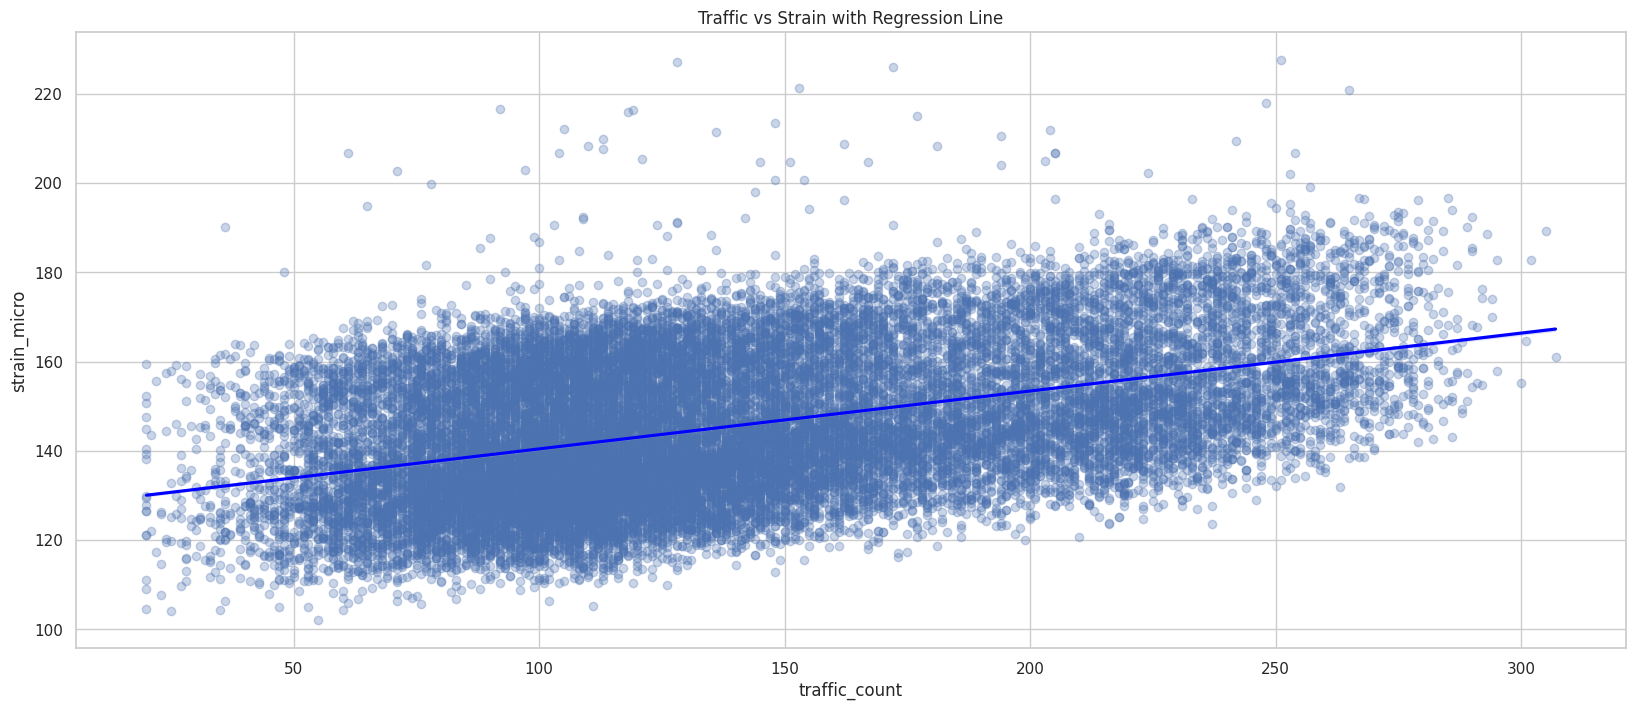

In [21]:
plt.figure(figsize=(20,8))
sns.regplot(
    data=df,
    x="traffic_count",
    y="strain_micro",
    scatter_kws={"alpha":0.3},
    line_kws={"color":"blue"}
)
plt.title("Traffic vs Strain with Regression Line")
plt.show()

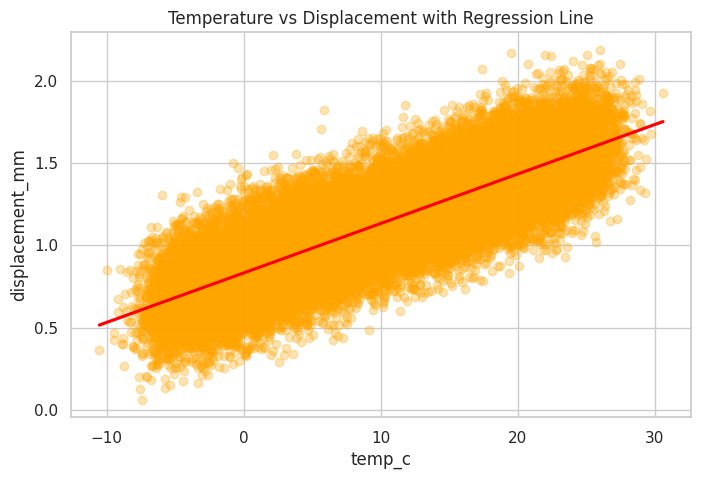

In [22]:
plt.figure(figsize=(8,5))
sns.regplot(
    data=df,
    x="temp_c",
    y="displacement_mm",
    scatter_kws={"alpha":0.3, "color":"orange"},
    line_kws={"color":"red"}
)
plt.title("Temperature vs Displacement with Regression Line")
plt.show()

# Part B

Time features were not included in the regression model since strain is directly explained by physical variables. However, for anomaly detection, temporal context such as hour or weekday can improve performance by distinguishing expected from unusual behavior.

In [23]:
df_org

,timestamp,bridge_id,temp_c,humidity,traffic_count,truck_count,wind_speed,strain_micro,vibration_mm,tilt_deg,displacement_mm,crack_sensor,anomaly
0,2025-01-01 00:00:00,1,-1.25,69.9,136,4,4.52,130.99,1.602,0.0219,0.692,0.1227,0
1,2025-01-01 01:00:00,1,-1.82,66.3,132,7,1.26,126.52,1.381,0.0186,0.640,0.1093,0
2,2025-01-01 02:00:00,1,0.10,62.8,122,2,3.32,132.22,1.368,0.0197,0.713,0.1293,0
3,2025-01-01 03:00:00,1,0.03,70.0,128,2,3.64,135.53,1.661,0.0227,0.834,0.1244,0
4,2025-01-01 04:00:00,1,1.29,67.8,118,5,2.39,136.69,1.417,0.0167,0.887,0.1181,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26275,2025-12-31 19:00:00,3,-8.80,66.1,189,12,3.45,129.69,1.453,0.0150,0.400,0.1804,0
26276,2025-12-31 20:00:00,3,-6.64,83.5,127,8,3.32,115.94,1.300,0.0178,0.470,0.1733,0
26277,2025-12-31 21:00:00,3,-3.95,61.7,124,4,3.94,114.97,1.232,0.0151,0.641,0.1761,0
26278,2025-12-31 22:00:00,3,-4.75,68.6,96,3,4.60,117.87,1.168,0.0135,0.470,0.1780,0


In [24]:
df=df_org.copy()
drop_cols = ["strain_micro", "timestamp", "anomaly"]
X = df.drop(columns=drop_cols)
y = df["strain_micro"]
X.head()

,bridge_id,temp_c,humidity,traffic_count,truck_count,wind_speed,vibration_mm,tilt_deg,displacement_mm,crack_sensor
0,1,-1.25,69.9,136,4,4.52,1.602,0.0219,0.692,0.1227
1,1,-1.82,66.3,132,7,1.26,1.381,0.0186,0.640,0.1093
2,1,0.10,62.8,122,2,3.32,1.368,0.0197,0.713,0.1293
3,1,0.03,70.0,128,2,3.64,1.661,0.0227,0.834,0.1244
4,1,1.29,67.8,118,5,2.39,1.417,0.0167,0.887,0.1181


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)


mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mape= mean_absolute_percentage_error(y_test, y_pred_lr)

print(f"MAE:{mae:.2f}")
print(f"MAPE:{mape*100:.2f}%")
print(f"RMSE: {rmse:.2f}")

MAE:4.17
MAPE:2.89%
RMSE: 5.28


Result: The relatively low MAPE suggests that strain is largely explainable by the available features, indicating stable and predictable structural behavior.

In [26]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf)

print("RF MAE:", mae_rf)
print(f"MAPE:{mape*100:.2f}%")
print("RF RMSE:", rmse_rf)

RF MAE: 3.4185925418569254
MAPE:2.89%
RF RMSE: 4.425832260395929


In [27]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, mae_rf],
    "RMSE": [rmse, rmse_rf],
    "MAPE (%)": [mape*100, mape_rf*100]
})

display(results.round(2))

,Model,MAE,RMSE,MAPE (%)
0,Linear Regression,4.17,5.28,2.89
1,Random Forest,3.42,4.43,2.36


Random Forest improves both MAE and RMSE, indicating better handling of non-linear relationships, while similar MAPE suggests overall prediction stability across models.

In [28]:
importances = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feat_imp

,Feature,Importance
7,tilt_deg,0.542304
6,vibration_mm,0.137005
1,temp_c,0.114057
3,traffic_count,0.095291
0,bridge_id,0.040816
4,truck_count,0.027390
8,displacement_mm,0.019809
9,crack_sensor,0.009013
2,humidity,0.007302
5,wind_speed,0.007014


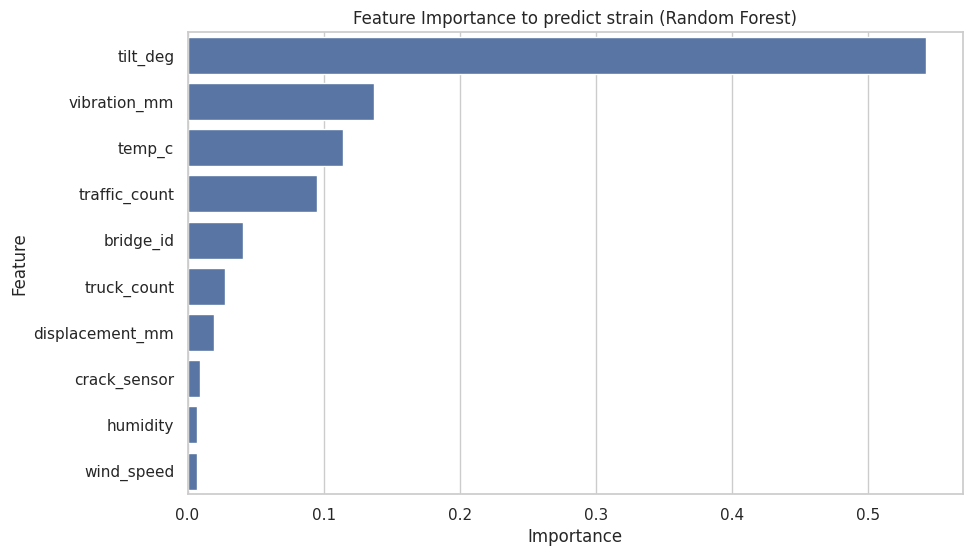

In [29]:
plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp, x="Importance", y="Feature")
plt.title("Feature Importance to predict strain (Random Forest)")
plt.show()

1. Tilt shows the highest importance, suggesting that structural deformation or angular shifts are the strongest predictor of strain.

2. Vibration contributes significantly, indicating that dynamic forces, such as traffic movement or wind, influence structural strain.
3. Temperature also plays a relevant role, supporting the presence of thermal expansion effects on structural strain.
4. Interestingly, traffic-related variables are not among the top predictors, suggesting that their effect may already be indirectly captured through vibration and tilt measurements.

# part c

In [30]:
df=df_extra.copy()

In [49]:
# Target
y_class = df["anomaly"]

# Features
X_class = df.drop(columns=["anomaly", "timestamp"])

# Keep only numeric columns
X_class = X_class.select_dtypes(include=[np.number])

X_class.head()

,bridge_id,temp_c,humidity,traffic_count,truck_count,wind_speed,strain_micro,vibration_mm,tilt_deg,displacement_mm,crack_sensor,hour,day
0,1,-1.25,69.9,136,4,4.52,130.99,1.602,0.0219,0.692,0.1227,0,1
1,1,-1.82,66.3,132,7,1.26,126.52,1.381,0.0186,0.640,0.1093,1,1
2,1,0.10,62.8,122,2,3.32,132.22,1.368,0.0197,0.713,0.1293,2,1
3,1,0.03,70.0,128,2,3.64,135.53,1.661,0.0227,0.834,0.1244,3,1
4,1,1.29,67.8,118,5,2.39,136.69,1.417,0.0167,0.887,0.1181,4,1


In [32]:
df["anomaly"].nunique()
df["anomaly"].value_counts(normalize=True) * 100

,proportion
anomaly,
0,99.592846
1,0.407154


In [50]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)



rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_clf.fit(X_train_c, y_train_c)
y_pred_c = rf_clf.predict(X_test_c)


In [51]:
y_proba_c = rf_clf.predict_proba(X_test_c)[:,1]
y_proba_c


array([0., 0., 0., ..., 0., 0., 0.])

In [52]:
df["anomaly"].value_counts(normalize=True)

,proportion
anomaly,
0,0.995928
1,0.004072


In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report

accuracy = accuracy_score(y_test_c, y_pred_c)
precision = precision_score(y_test_c, y_pred_c)
recall = recall_score(y_test_c, y_pred_c)
roc_auc = roc_auc_score(y_test_c, y_proba_c)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("ROC-AUC:", roc_auc)

print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_c))

Accuracy: 0.9994292237442922
Precision: 1.0
Recall: 0.8571428571428571
ROC-AUC: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5235
           1       1.00      0.86      0.92        21

    accuracy                           1.00      5256
   macro avg       1.00      0.93      0.96      5256
weighted avg       1.00      1.00      1.00      5256



In [54]:
feat_imp_c = pd.DataFrame({
    "Feature": X_class.columns,
    "Importance": rf_clf.feature_importances_
}).sort_values("Importance", ascending=False)

feat_imp_c

,Feature,Importance
7,vibration_mm,0.445105
8,tilt_deg,0.297027
6,strain_micro,0.187749
3,traffic_count,0.015910
9,displacement_mm,0.011006
10,crack_sensor,0.010020
1,temp_c,0.006648
2,humidity,0.005962
4,truck_count,0.005191
5,wind_speed,0.005069


In [39]:
df

,timestamp,bridge_id,temp_c,humidity,traffic_count,truck_count,wind_speed,strain_micro,vibration_mm,tilt_deg,displacement_mm,crack_sensor,anomaly,hour,day,weekday
0,2025-01-01 00:00:00,1,-1.25,69.9,136,4,4.52,130.99,1.602,0.0219,0.692,0.1227,0,0,1,Wednesday
1,2025-01-01 01:00:00,1,-1.82,66.3,132,7,1.26,126.52,1.381,0.0186,0.640,0.1093,0,1,1,Wednesday
2,2025-01-01 02:00:00,1,0.10,62.8,122,2,3.32,132.22,1.368,0.0197,0.713,0.1293,0,2,1,Wednesday
3,2025-01-01 03:00:00,1,0.03,70.0,128,2,3.64,135.53,1.661,0.0227,0.834,0.1244,0,3,1,Wednesday
4,2025-01-01 04:00:00,1,1.29,67.8,118,5,2.39,136.69,1.417,0.0167,0.887,0.1181,0,4,1,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26275,2025-12-31 19:00:00,3,-8.80,66.1,189,12,3.45,129.69,1.453,0.0150,0.400,0.1804,0,19,31,Wednesday
26276,2025-12-31 20:00:00,3,-6.64,83.5,127,8,3.32,115.94,1.300,0.0178,0.470,0.1733,0,20,31,Wednesday
26277,2025-12-31 21:00:00,3,-3.95,61.7,124,4,3.94,114.97,1.232,0.0151,0.641,0.1761,0,21,31,Wednesday
26278,2025-12-31 22:00:00,3,-4.75,68.6,96,3,4.60,117.87,1.168,0.0135,0.470,0.1780,0,22,31,Wednesday


In [55]:
X_class = df.drop(columns=[
    "anomaly",
    "timestamp",
    "strain_micro",   # remove
    "tilt_deg"        # maybe remove
])
X_class = X_class.select_dtypes(include=[np.number])

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)



rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_clf.fit(X_train_c, y_train_c)
y_pred_c = rf_clf.predict(X_test_c)
y_proba_c = rf_clf.predict_proba(X_test_c)[:,1]
accuracy = accuracy_score(y_test_c, y_pred_c)
precision = precision_score(y_test_c, y_pred_c)
recall = recall_score(y_test_c, y_pred_c)
roc_auc = roc_auc_score(y_test_c, y_proba_c)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("ROC-AUC:", roc_auc)

print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_c))

Accuracy: 0.9994292237442922
Precision: 1.0
Recall: 0.8571428571428571
ROC-AUC: 0.9998681038795653

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5235
           1       1.00      0.86      0.92        21

    accuracy                           1.00      5256
   macro avg       1.00      0.93      0.96      5256
weighted avg       1.00      1.00      1.00      5256



In [42]:
df.groupby("anomaly")["crack_sensor"].mean()

,crack_sensor
anomaly,
0,0.173796
1,0.177794


In [43]:
df.groupby("anomaly")[X_class.columns].mean().T.sort_values(by=1, ascending=False)

anomaly,0,1
traffic_count,139.282008,141.401869
humidity,65.014660,63.933645
day,15.720322,15.775701
truck_count,10.919039,11.028037
hour,11.502121,10.981308
temp_c,9.998321,10.844393
wind_speed,3.030545,2.975140
vibration_mm,1.496447,2.729187
bridge_id,2.000267,1.934579
displacement_mm,1.132958,1.145785


In [56]:
feat_imp_c = pd.DataFrame({
    "Feature": X_class.columns,
    "Importance": rf_clf.feature_importances_
}).sort_values("Importance", ascending=False)

feat_imp_c

,Feature,Importance
6,vibration_mm,0.805232
3,traffic_count,0.036633
7,displacement_mm,0.023547
2,humidity,0.022458
8,crack_sensor,0.021852
1,temp_c,0.019723
5,wind_speed,0.018602
9,hour,0.017858
4,truck_count,0.016834
10,day,0.014165


The results show that anomaly detection is primarily driven by structural response variables such as vibration, tilt, and strain. These features exhibit strong redundancy, as removing some of them shifts importance to the remaining ones without significantly degrading performance.

This suggests that the sensor system provides overlapping measurements of structural behavior, enabling robust anomaly detection even when certain signals are unavailable.(This suggests that the sensor system provides overlapping measurements of structural behavior, enabling robust anomaly detection even when certain signals are unavailable.)

# D

In [59]:
# =========================
# Part D: Anomaly Detection
# Isolation Forest
# =========================

from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd

# 1. Prepare features, do NOT use anomaly label for training
X_unsup = df.drop(columns=["anomaly", "timestamp"])
X_unsup = X_unsup.select_dtypes(include=[np.number])

# 2. Train Isolation Forest
iso = IsolationForest(
    n_estimators=100,
    contamination=0.01,   # expected anomaly share
    random_state=42
)

iso.fit(X_unsup)

# 3. Predict anomalies
# Isolation Forest gives:
#  1  = normal
# -1  = anomaly
y_pred_iso_raw = iso.predict(X_unsup)

# 4. Convert to normal ML format:
# 0 = normal, 1 = anomaly
y_pred_iso = np.where(y_pred_iso_raw == -1, 1, 0)

# 5. Check how many anomalies were detected
print("Detected classes:")
print(pd.Series(y_pred_iso).value_counts())

# 6. Compare with true labels
print("\nConfusion Matrix:")
print(confusion_matrix(df["anomaly"], y_pred_iso))

print("\nClassification Report:")
print(classification_report(df["anomaly"], y_pred_iso))

Detected classes:
0    26017
1      263
Name: count, dtype: int64

Confusion Matrix:
[[25981   192]
 [   36    71]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     26173
           1       0.27      0.66      0.38       107

    accuracy                           0.99     26280
   macro avg       0.63      0.83      0.69     26280
weighted avg       1.00      0.99      0.99     26280

